# Laboratorio 2: Deep Learning aplicado a series de tiempo

**Integrantes:** Isabella Recinos Rodríguez (23003), Sofía López Ayerdi (231929), Nils Muralles Morales (23727)

Esta libreta desarrolla el ejercicio 1 (modelos LSTM) para la serie de **Europa**, dentro de la categoría Regiones Geográficas trabajada en el Laboratorio 1. Se usan los mismos conjuntos de entrenamiento y prueba que en la entrega anterior (corte en marzo de 2021, 147 meses de entrenamiento y 63 de prueba).

Se construyen dos modelos LSTM con configuraciones distintas para esta serie: el modelo A (esta sección, LSTM simple con ventana de 12 meses) y el modelo B (configuración de la compañera encargada de esta serie), cada uno con su propio tuneo de hiperparámetros, para después compararlos entre sí y contra el mejor modelo del Laboratorio 1.

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
from sklearn.preprocessing import MinMaxScaler
from sklearn.metrics import mean_absolute_error, mean_squared_error

import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers

DATA_PATH = "Laboratorio 1. Series de Tiempo 2026 - Base_Migracion_2009-2026jun.xlsx"

# Mismo estilo visual que en las libretas del Laboratorio 1
PALETTE = ["#2a78d6", "#eb6834", "#1baf7a", "#eda100",
           "#e87ba4", "#008300", "#4a3aa7", "#e34948"]

plt.rcParams.update({
    "figure.facecolor": "#fcfcfb",
    "axes.facecolor": "#fcfcfb",
    "axes.edgecolor": "#c3c2b7",
    "axes.labelcolor": "#0b0b0b",
    "axes.titlecolor": "#0b0b0b",
    "text.color": "#0b0b0b",
    "xtick.color": "#52514e",
    "ytick.color": "#52514e",
    "grid.color": "#e1e0d9",
    "axes.grid": True,
    "grid.linewidth": 0.7,
    "axes.spines.top": False,
    "axes.spines.right": False,
    "font.size": 11,
    "figure.dpi": 100,
})

pd.set_option("display.max_columns", 20)
pd.set_option("display.width", 140)

SEED = 42
np.random.seed(SEED)
tf.random.set_seed(SEED)

df = pd.read_excel(DATA_PATH, sheet_name="Datos")
df["fecha"] = pd.to_datetime(dict(year=df["Año"], month=df["Mes cod"], day=1))

print(f"Dimensiones del dataset: {df.shape[0]:,} filas x {df.shape[1]} columnas")

Dimensiones del dataset: 161,036 filas x 14 columnas


## 1. División en entrenamiento y prueba

Se recupera el mismo corte 70/30 usado en el Laboratorio 1, para que los modelos LSTM se entrenen y evalúen exactamente sobre los mismos periodos que los modelos ARIMA, Prophet, Holt-Winters y compañía.

In [2]:
fechas_unicas = sorted(df["fecha"].unique())
n_meses = len(fechas_unicas)
corte_idx = int(n_meses * 0.7) - 1
fecha_corte = fechas_unicas[corte_idx]

train = df[df["fecha"] <= fecha_corte].copy()
test = df[df["fecha"] > fecha_corte].copy()

print(f"Fecha de corte: {pd.Timestamp(fecha_corte).strftime('%Y-%m')}")
print(f"Entrenamiento: {train['fecha'].min().strftime('%Y-%m')} a {train['fecha'].max().strftime('%Y-%m')} ({train['fecha'].nunique()} meses)")
print(f"Prueba:        {test['fecha'].min().strftime('%Y-%m')} a {test['fecha'].max().strftime('%Y-%m')} ({test['fecha'].nunique()} meses)")

Fecha de corte: 2021-03
Entrenamiento: 2009-01 a 2021-03 (147 meses)
Prueba:        2021-04 a 2026-06 (63 meses)


## 2. Construcción de la serie de Europa (entrenamiento y prueba)

Se reconstruye la serie mensual de Europa (variable `Región dos`), tanto para entrenamiento como para prueba, con la misma lógica de la libreta de Regiones Geográficas: se suma `Viajero` por mes y se rellenan con 0 los meses sin registros, ya que esos ceros son reales (cierre de fronteras en 2020), no huecos de captura.

In [3]:
rango_train = pd.date_range(train["fecha"].min(), train["fecha"].max(), freq="MS")
rango_test = pd.date_range(test["fecha"].min(), test["fecha"].max(), freq="MS")

s_europa_train = train[train["Región dos"] == "Europa"].groupby("fecha")["Viajero"].sum()
s_europa_train = s_europa_train.reindex(rango_train, fill_value=0.0)
s_europa_train.index.name = "fecha"

s_europa_test = test[test["Región dos"] == "Europa"].groupby("fecha")["Viajero"].sum()
s_europa_test = s_europa_test.reindex(rango_test, fill_value=0.0)
s_europa_test.index.name = "fecha"

print(f"Entrenamiento: {len(s_europa_train)} meses, media = {s_europa_train.mean():,.0f}, máximo = {s_europa_train.max():,.0f}")
print(f"Prueba:        {len(s_europa_test)} meses, media = {s_europa_test.mean():,.0f}, máximo = {s_europa_test.max():,.0f}")

Entrenamiento: 147 meses, media = 9,877, máximo = 16,804
Prueba:        63 meses, media = 12,234, máximo = 23,384


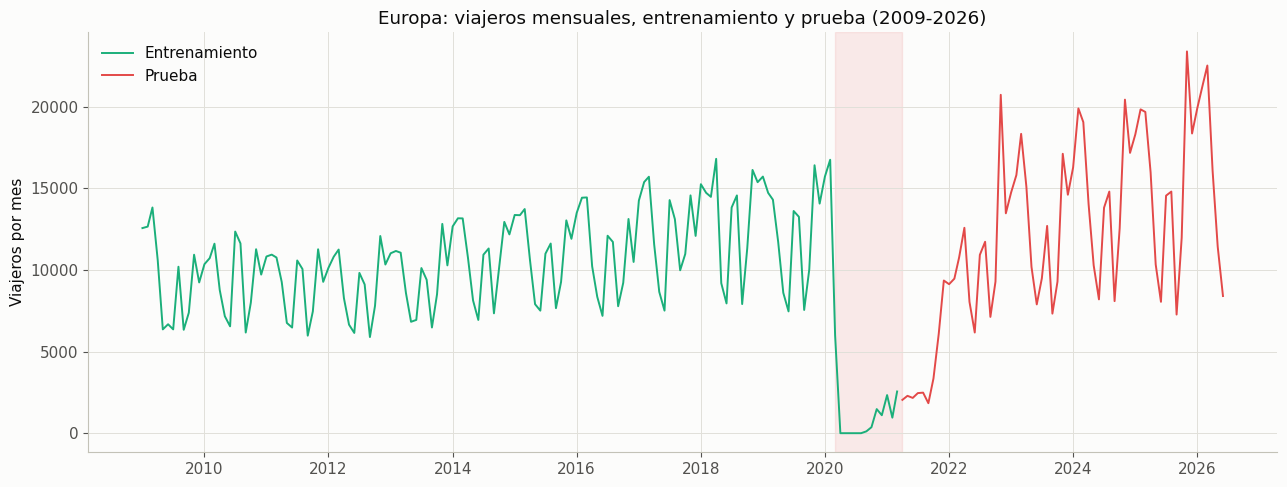

In [4]:
fig, ax = plt.subplots(figsize=(13, 5))
ax.plot(s_europa_train.index, s_europa_train.values, color=PALETTE[2], linewidth=1.4, label="Entrenamiento")
ax.plot(s_europa_test.index, s_europa_test.values, color=PALETTE[7], linewidth=1.4, label="Prueba")
ax.axvspan(pd.Timestamp("2020-03-01"), pd.Timestamp("2021-03-31"), color=PALETTE[7], alpha=0.10)
ax.set_title("Europa: viajeros mensuales, entrenamiento y prueba (2009-2026)")
ax.set_ylabel("Viajeros por mes")
ax.legend(frameon=False)
plt.tight_layout()
plt.show()

## 3. Modelo A: LSTM simple con ventana de 12 meses

**Configuración:** una sola capa LSTM, con ventana (look-back) de 12 meses, es decir, se usan los 12 valores anteriores para predecir el siguiente. Se eligió esta ventana porque coincide con un ciclo estacional completo, que es justamente el patrón más marcado de esta serie según el EDA y la descomposición del Laboratorio 1.

**Preprocesamiento:** igual que para los modelos ARIMA del Laboratorio 1, se aplica `log1p` para estabilizar la varianza (la correlación entre nivel y dispersión anual bajaba de 0.82 a 0.22 con logaritmo). Después se escala a [0, 1] con un `MinMaxScaler` ajustado solo con el entrenamiento, como corresponde para no filtrar información de prueba al ajuste.

In [5]:
LOOK_BACK = 12

log_train = np.log1p(s_europa_train.values).reshape(-1, 1)
log_test = np.log1p(s_europa_test.values).reshape(-1, 1)

scaler = MinMaxScaler()
scaled_train = scaler.fit_transform(log_train)
scaled_test = scaler.transform(log_test)


def crear_ventanas(serie, look_back):
    X, y = [], []
    for i in range(len(serie) - look_back):
        X.append(serie[i:i + look_back, 0])
        y.append(serie[i + look_back, 0])
    return np.array(X), np.array(y)


X_train, y_train = crear_ventanas(scaled_train, LOOK_BACK)
X_train = X_train.reshape((X_train.shape[0], X_train.shape[1], 1))

print(f"X_train: {X_train.shape}, y_train: {y_train.shape}")

X_train: (135, 12, 1), y_train: (135,)


### 3.1 Tuneo de hiperparámetros

Se prueban distintas combinaciones de número de unidades y tasa de aprendizaje, usando el último 20% del entrenamiento como validación (respetando el orden temporal, sin mezclar meses). Se compara por el error cuadrático medio de validación y se elige la combinación con menor error.

In [6]:
val_size = int(len(X_train) * 0.2)
X_tr, X_val = X_train[:-val_size], X_train[-val_size:]
y_tr, y_val = y_train[:-val_size], y_train[-val_size:]

grid_unidades = [16, 32, 64]
grid_lr = [1e-2, 1e-3]

resultados_tuneo = []

for unidades in grid_unidades:
    for lr in grid_lr:
        keras.utils.set_random_seed(SEED)
        modelo = keras.Sequential([
            layers.Input(shape=(LOOK_BACK, 1)),
            layers.LSTM(unidades),
            layers.Dense(1),
        ])
        modelo.compile(optimizer=keras.optimizers.Adam(learning_rate=lr), loss="mse")
        historia = modelo.fit(X_tr, y_tr, validation_data=(X_val, y_val),
                               epochs=100, batch_size=8, verbose=0)
        val_loss = min(historia.history["val_loss"])
        resultados_tuneo.append({"unidades": unidades, "learning_rate": lr, "val_mse": val_loss})

tabla_tuneo = pd.DataFrame(resultados_tuneo).sort_values("val_mse").reset_index(drop=True)
tabla_tuneo

,unidades,learning_rate,val_mse
0,32,0.010,0.100662
1,64,0.010,0.103192
2,16,0.010,0.110986
3,16,0.001,0.118065
4,32,0.001,0.120390
5,64,0.001,0.127435


La combinación con menor error de validación se usa para entrenar el modelo final, ahora sí con todo el conjunto de entrenamiento (sin reservar validación), para aprovechar toda la información disponible antes de predecir sobre prueba.

In [7]:
mejor = tabla_tuneo.iloc[0]
mejores_unidades = int(mejor["unidades"])
mejor_lr = float(mejor["learning_rate"])

print(f"Mejor configuración: unidades={mejores_unidades}, learning_rate={mejor_lr}, val_mse={mejor['val_mse']:.5f}")

keras.utils.set_random_seed(SEED)
modelo_a = keras.Sequential([
    layers.Input(shape=(LOOK_BACK, 1)),
    layers.LSTM(mejores_unidades),
    layers.Dense(1),
])
modelo_a.compile(optimizer=keras.optimizers.Adam(learning_rate=mejor_lr), loss="mse")
historia_final = modelo_a.fit(X_train, y_train, epochs=150, batch_size=8, verbose=0)

print(f"Pérdida final de entrenamiento (mse en escala escalada): {historia_final.history['loss'][-1]:.5f}")

Mejor configuración: unidades=32, learning_rate=0.01, val_mse=0.10066


Pérdida final de entrenamiento (mse en escala escalada): 0.00676


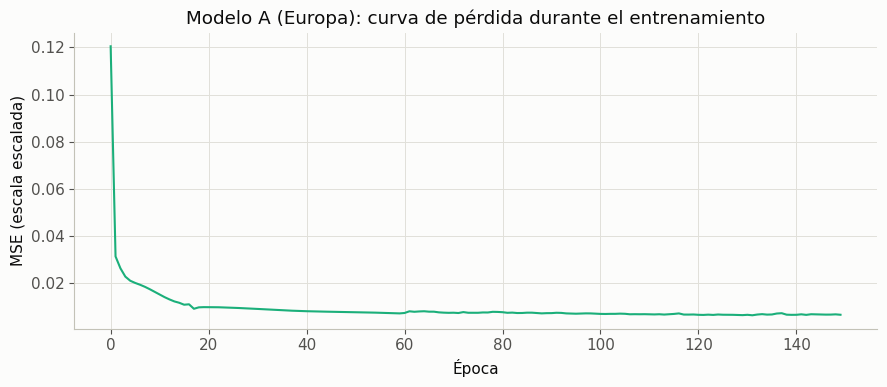

In [8]:
fig, ax = plt.subplots(figsize=(9, 4))
ax.plot(historia_final.history["loss"], color=PALETTE[2])
ax.set_title("Modelo A (Europa): curva de pérdida durante el entrenamiento")
ax.set_xlabel("Época")
ax.set_ylabel("MSE (escala escalada)")
plt.tight_layout()
plt.show()

## 4. Predicción sobre el conjunto de prueba

Como el LSTM predice un mes a la vez a partir de los 12 meses anteriores, para pronosticar los 63 meses de prueba se hace una predicción **recursiva**: se predice el primer mes de prueba con los últimos 12 meses reales de entrenamiento, y luego cada predicción nueva se va agregando a la ventana para predecir el siguiente mes, encadenando así todo el horizonte de prueba.

In [9]:
def predecir_recursivo(modelo, serie_escalada_completa, look_back, n_pasos):
    ventana = list(serie_escalada_completa[-look_back:, 0])
    predicciones = []
    for _ in range(n_pasos):
        entrada = np.array(ventana[-look_back:]).reshape((1, look_back, 1))
        pred = modelo.predict(entrada, verbose=0)[0, 0]
        predicciones.append(pred)
        ventana.append(pred)
    return np.array(predicciones)


pred_escalada_a = predecir_recursivo(modelo_a, scaled_train, LOOK_BACK, len(s_europa_test))
pred_log_a = scaler.inverse_transform(pred_escalada_a.reshape(-1, 1)).flatten()
pred_a = np.expm1(pred_log_a)
pred_a = np.clip(pred_a, 0, None)

pred_a_serie = pd.Series(pred_a, index=s_europa_test.index)
pred_a_serie.head()

fecha
2021-04-01     7909.569336
2021-05-01    19903.150391
2021-06-01    25170.187500
2021-07-01    19225.359375
2021-08-01    13099.763672
Freq: MS, dtype: float32

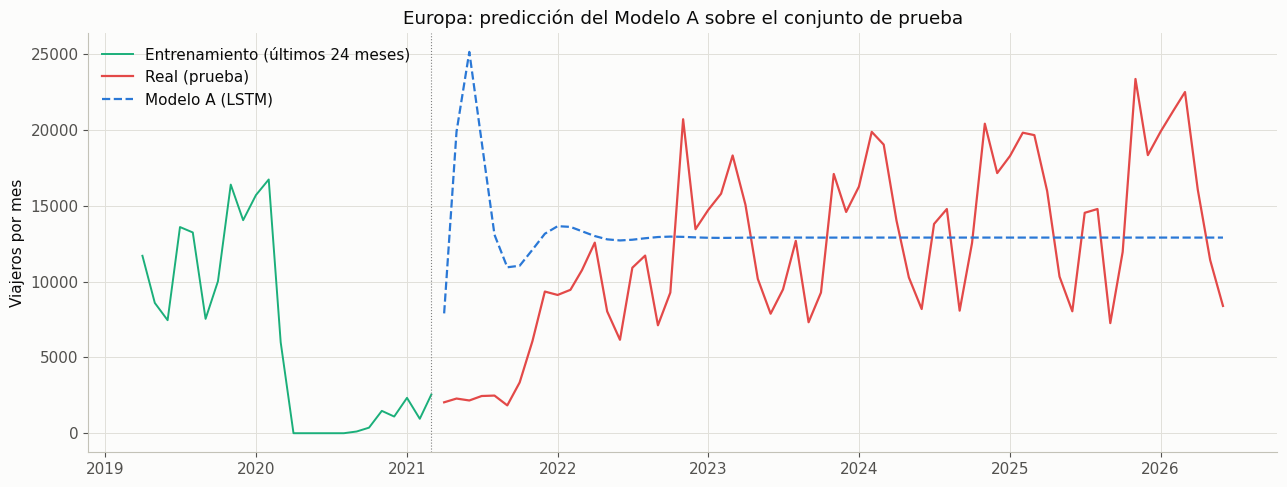

In [10]:
fig, ax = plt.subplots(figsize=(13, 5))
ax.plot(s_europa_train.index[-24:], s_europa_train.values[-24:], color=PALETTE[2], linewidth=1.4, label="Entrenamiento (últimos 24 meses)")
ax.plot(s_europa_test.index, s_europa_test.values, color=PALETTE[7], linewidth=1.6, label="Real (prueba)")
ax.plot(pred_a_serie.index, pred_a_serie.values, color=PALETTE[0], linewidth=1.6, linestyle="--", label="Modelo A (LSTM)")
ax.axvline(s_europa_train.index[-1], color="gray", linewidth=0.8, linestyle=":")
ax.set_title("Europa: predicción del Modelo A sobre el conjunto de prueba")
ax.set_ylabel("Viajeros por mes")
ax.legend(frameon=False)
plt.tight_layout()
plt.show()

Un hallazgo importante de esta gráfica: el pronóstico del Modelo A captura bien el primer año de prueba, pero después la predicción recursiva pierde la oscilación estacional y se aplana alrededor de las 13,000 unidades, muy cerca del nivel medio del entrenamiento. Esto es una limitación conocida de encadenar predicciones de un LSTM que solo ve el valor pasado de la propia serie, sin ninguna señal de en qué mes del año está: cada predicción nueva se acerca un poco más al promedio, y con un horizonte tan largo (63 meses) el efecto se acumula hasta borrar la estacionalidad. Es justo el problema que la configuración de mes codificado (seno y coseno) del Modelo B podría ayudar a resolver.

In [11]:
mae_a = mean_absolute_error(s_europa_test.values, pred_a)
rmse_a = np.sqrt(mean_squared_error(s_europa_test.values, pred_a))

print(f"Modelo A (LSTM simple, ventana 12): MAE = {mae_a:,.0f}   RMSE = {rmse_a:,.0f}")

Modelo A (LSTM simple, ventana 12): MAE = 5,043   RMSE = 6,492


## 5. Modelo B (pendiente)

Aquí se agrega la segunda configuración de LSTM para la serie de Europa, con una arquitectura distinta a la del Modelo A (por ejemplo, una red apilada de 2 capas con ventana de 24 meses, o una versión con el mes del año codificado como variable adicional), incluyendo su propio proceso de tuneo de hiperparámetros.

Una vez estén ambos modelos, se compara su MAE y RMSE sobre el mismo conjunto de prueba para decidir cuál es mejor para esta serie, y ese resultado se contrasta después con el mejor modelo del Laboratorio 1 (Prophet, SARIMA, Holt-Winters, SES o naive estacional, según corresponda a Europa).